# All EarthCARE Data Plots
Plots from `combined_all_*_latheight.nc` — ATL_TC + ATL_ICE + ATL_EBD combined.

| Section | Plots |
|---------|-------|
| A | Cross-sections: occurrence, temperature, depol, extinction, lidar ratio, backscatter, IWC, eff radius |
| B | Variability: std maps for IWC and EBD variables |
| C | 1D latitudinal profiles (height-averaged) |
| D | Scatter: depol vs r_eff, extinction vs IWC, depol vs T |

**0. Imports & load data**

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

DATA_FILE = Path("/Users/tobiasraucher/Python/KNMI/output/combined_all_1.0deg_20251201_20251231_latheight.nc")
OUT_DIR   = Path("/Users/tobiasraucher/Python/KNMI/output/figures")
OUT_DIR.mkdir(exist_ok=True)

ds  = xr.open_dataset(DATA_FILE)
lat = ds["latitude"].values
h   = ds["height"].values / 1000   # m → km

# Drop below-ground height levels
above = h >= 0
h = h[above]

# ATL_TC
occ  = ds["atl_tc_occurrence"].values[:, above]
temp = ds["atl_tc_temperature"].values[:, above]

# ATL_ICE (original units: kg m⁻³ and m)
iwc    = ds["iwc_mean"].values[:, above]
iwc_s  = ds["iwc_std"].values[:, above]
iwc_e  = ds["iwc_err_mean"].values[:, above]
reff   = ds["eff_radius_mean"].values[:, above]
reff_s = ds["eff_radius_std"].values[:, above]

# ATL_EBD (original units: m⁻¹, m⁻¹ sr⁻¹, sr, dimensionless)
depol    = ds["depol_ratio_mean"].values[:, above]
depol_s  = ds["depol_ratio_std"].values[:, above]
ext      = ds["extinction_mean"].values[:, above]
ext_s    = ds["extinction_std"].values[:, above]
bsc      = ds["backscatter_mean"].values[:, above]
lr       = ds["lidar_ratio_mean"].values[:, above]
lr_s     = ds["lidar_ratio_std"].values[:, above]
tot_bsc  = ds["total_bsc_mean"].values[:, above]
mie_bsc  = ds["mie_total_bsc_mean"].values[:, above]

print(f"Loaded: {DATA_FILE.name}")
print(f"Lat: {lat[0]:.0f}..{lat[-1]:.0f}°   Height: {h[0]:.3f}..{h[-1]:.1f} km   Shape: {occ.shape}")

Loaded: combined_all_1.0deg_20251201_20251231_latheight.nc
Lat: -90..90°   Height: 19.920..0.1 km   Shape: (180, 194)


**Helper: standard cross-section plot**

In [2]:
def cross_section(data, lat, h, title, cbar_label, cmap="viridis",
                  vmin=None, vmax=None, occ_contours=True, occ_color="white",
                  log_scale=False, occ_thresh=0.05, fname=None):
    """Standard lat-height filled contour with optional occurrence contour overlay.

    log_scale   : use LogNorm for the colour mapping
    occ_thresh  : when log_scale=True, percentile bounds are computed only from
                  cells where occ >= occ_thresh, so the colour range reflects
                  variation inside the ice cloud regions rather than the full grid.
    """
    fig, ax = plt.subplots(figsize=(10, 5))

    if log_scale:
        # Restrict range computation to well-sampled (high-occurrence) pixels
        occ_mask = occ >= occ_thresh
        inside = data[occ_mask]
        inside = inside[inside > 0]
        vmin_ = vmin if vmin is not None else np.nanpercentile(inside, 2)
        vmax_ = vmax if vmax is not None else np.nanpercentile(inside, 98)
        norm = mcolors.LogNorm(vmin=vmin_, vmax=vmax_)
        mesh = ax.pcolormesh(lat, h, data.T, cmap=cmap, norm=norm, shading="auto")
    else:
        vmax_ = vmax if vmax is not None else np.nanpercentile(data, 99)
        vmin_ = vmin if vmin is not None else 0
        mesh = ax.pcolormesh(lat, h, data.T, cmap=cmap,
                             vmin=vmin_, vmax=vmax_, shading="auto")

    plt.colorbar(mesh, ax=ax, label=cbar_label, pad=0.02)
    if occ_contours:
        cs = ax.contour(lat, h, occ.T, levels=[0.05, 0.15, 0.30],
                        colors=occ_color, linewidths=0.8, alpha=0.7)
        ax.clabel(cs, fmt="%.2f", fontsize=7, inline=True)
    ax.set_xlabel("Latitude (°)")
    ax.set_ylabel("Height (km)")
    ax.set_title(title)
    ax.set_xlim(-90, 90)
    ax.set_xticks(range(-90, 91, 30))
    ax.set_ylim(0, 20)
    plt.tight_layout()
    if fname:
        plt.savefig(OUT_DIR / fname, dpi=300)
        print(f"Saved {fname}")
    plt.show()

## Section A — Cross-section maps

**A1. ATL_TC ice occurrence**

Saved A1_atl_tc_occurrence.png


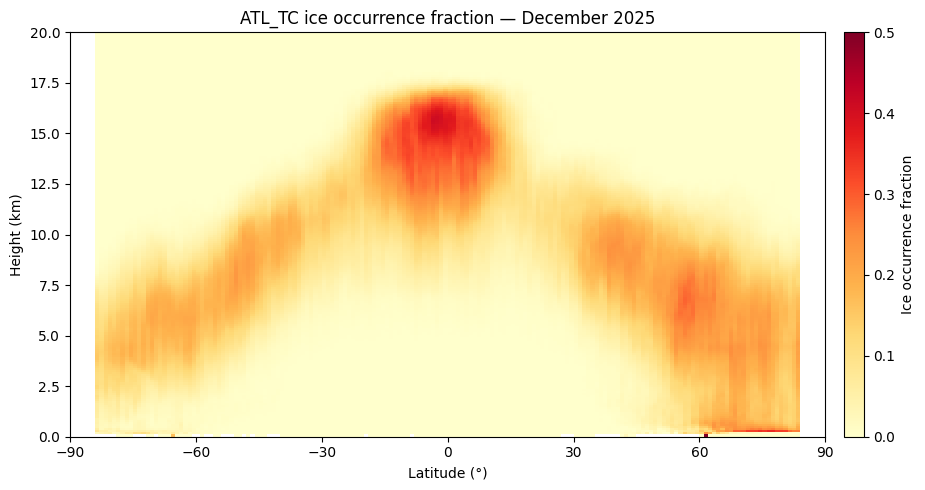

In [3]:
cross_section(occ, lat, h,
    title="ATL_TC ice occurrence fraction — December 2025",
    cbar_label="Ice occurrence fraction",
    cmap="YlOrRd", vmin=0, vmax=0.5,
    occ_contours=False,
    fname="A1_atl_tc_occurrence.png")

**A1.5 — Oct 2025 – Feb 2026 temperature (ATL_TC__2A)**

A1.5.1: world map (height-integrated column mean) · A1.5.2: lat/height cross-section (zonal mean)

In [4]:
# --- Load Oct–Feb temperature data ---
TEMP_LH_FILE = Path("/Users/tobiasraucher/Python/KNMI/output/"
                    "ATL_TC_2A_temperature_0.5deg_20251003_20260228_latheight.nc")
TEMP_3D_FILE = Path(str(TEMP_LH_FILE).replace("_latheight.nc", "_3d.nc"))

ds_t   = xr.open_dataset(TEMP_LH_FILE)
t_lat  = ds_t["latitude"].values
t_h    = ds_t["height"].values / 1000        # m → km
t_lh   = ds_t["temperature"].values          # (lat, height)
t_cnt  = ds_t["temp_count"].values

# Height-collapsed column mean for world map fallback / 1-D check
ts_col = np.nansum(ds_t["temperature"].values * t_cnt, axis=1)
tc_col = np.nansum(t_cnt, axis=1)
t_col  = np.divide(ts_col, tc_col, out=np.full_like(ts_col, np.nan), where=tc_col > 0)

print(f"Latheight: {ds_t['temperature'].shape}  lat {t_lat[0]:.2f}..{t_lat[-1]:.2f}  "
      f"h {t_h[0]:.1f}..{t_h[-1]:.1f} km")
print(f"Temp range: {np.nanmin(t_lh):.1f} – {np.nanmax(t_lh):.1f} K")
print(f"3D file {'found' if TEMP_3D_FILE.exists() else 'NOT found (needed for world map)'}: {TEMP_3D_FILE.name}")

Latheight: (360, 201)  lat -89.75..89.75  h 0.0..20.0 km
Temp range: 190.9 – 299.5 K
3D file found: ATL_TC_2A_temperature_0.5deg_20251003_20260228_3d.nc


**A1.5.1 — Temperature world map (height-integrated)**

/var/folders/vp/b00pzthx34g6lmnpx9qphb5h0000gn/T/ipykernel_73969/755827529.py:40: RuntimeWarning: invalid value encountered in divide
  t_map    = np.where(w_s > 0.1, t_s / w_s, np.nan)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


Saved A1.5.1_temperature_worldmap.png


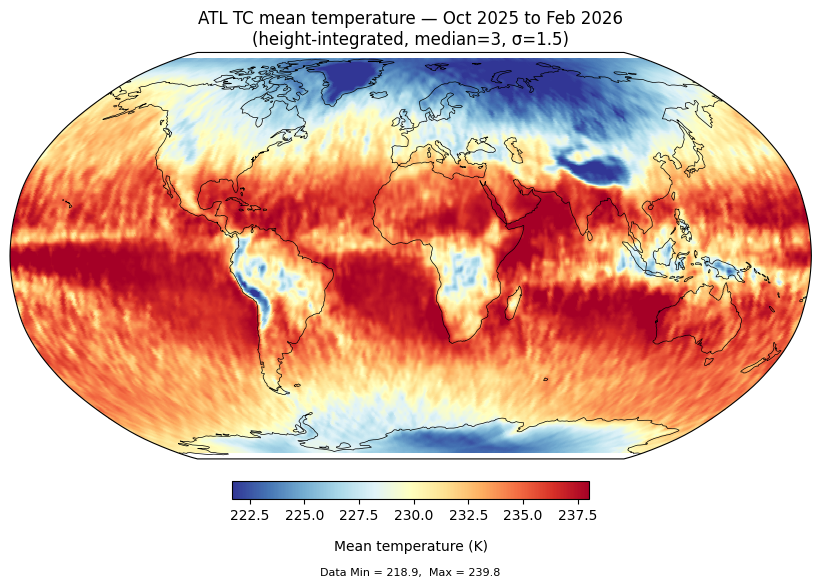

In [5]:
if not TEMP_3D_FILE.exists():
    print("3D file not found — copy it from the work PC first:")
    print(f"  {TEMP_3D_FILE}")
else:
    from scipy.ndimage import gaussian_filter, median_filter

    ds_3d   = xr.open_dataset(TEMP_3D_FILE)
    t3_lat  = ds_3d["latitude"].values
    t3_lon  = ds_3d["longitude"].values
    t3_cnt  = ds_3d["temp_count"].values
    t3_temp = ds_3d["temperature"].values

    ts_2d = np.nansum(t3_temp * t3_cnt, axis=2)
    tc_2d = np.nansum(t3_cnt,           axis=2)
    t_map = np.divide(ts_2d, tc_2d, out=np.full_like(ts_2d, np.nan), where=tc_2d > 0)

    # ── Outlier removal ──────────────────────────────────────────────────────
    MIN_COUNT     = 50     # ← mask cells with fewer samples than this
    # ─────────────────────────────────────────────────────────────────────────
    t_map[tc_2d < MIN_COUNT] = np.nan

    # ── Median filter (removes isolated blue/hot spots) ──────────────────────
    MEDIAN        = True   # ← set False to disable
    MEDIAN_SIZE   = 3      # ← neighbourhood size in grid cells (3 = 3×3 window)
    # ─────────────────────────────────────────────────────────────────────────
    if MEDIAN:
        nan_mask = np.isnan(t_map)
        t_m      = median_filter(np.where(nan_mask, np.nanmedian(t_map), t_map),
                                 size=MEDIAN_SIZE)
        t_map    = np.where(nan_mask, np.nan, t_m)

    # ── Gaussian smooth ──────────────────────────────────────────────────────
    SMOOTH        = True   # ← set False to disable
    SMOOTH_SIGMA  = 1.5    # ← larger = more smoothing (grid cells, ~0.5° each)
    # ─────────────────────────────────────────────────────────────────────────
    if SMOOTH:
        nan_mask = np.isnan(t_map)
        t_s      = gaussian_filter(np.where(nan_mask, 0, t_map), sigma=SMOOTH_SIGMA)
        w_s      = gaussian_filter((~nan_mask).astype(float),    sigma=SMOOTH_SIGMA)
        t_map    = np.where(w_s > 0.1, t_s / w_s, np.nan)

    vmin_m = np.nanpercentile(t_map, 2)
    vmax_m = np.nanpercentile(t_map, 98)

    try:
        import cartopy.crs as ccrs
        import cartopy.feature as cfeature
        fig = plt.figure(figsize=(14, 6))
        ax  = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())
        ax.set_global()
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color="k")
        im = ax.pcolormesh(t3_lon, t3_lat, t_map,
                           transform=ccrs.PlateCarree(),
                           cmap="RdYlBu_r", vmin=vmin_m, vmax=vmax_m)
    except ImportError:
        fig, ax = plt.subplots(figsize=(14, 6))
        im = ax.imshow(t_map, origin="lower", aspect="auto",
                       extent=[-180, 180, -90, 90],
                       cmap="RdYlBu_r", vmin=vmin_m, vmax=vmax_m)
        ax.set_xlabel("Longitude (°)"); ax.set_ylabel("Latitude (°)")

    smooth_label = f"median={MEDIAN_SIZE}, σ={SMOOTH_SIGMA}" if SMOOTH else "unsmoothed"
    cbar = plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.05, fraction=0.04)
    cbar.set_label("Mean temperature (K)", labelpad=12)   # ← increase for more spacing
    cbar.ax.text(0.5, -3.8,
                 f"Data Min = {np.nanmin(t_map):.1f},  Max = {np.nanmax(t_map):.1f}",
                 ha="center", va="top", transform=cbar.ax.transAxes, fontsize=8)
    ax.set_title(f"ATL TC mean temperature — Oct 2025 to Feb 2026\n"
                 f"(height-integrated, {smooth_label})", fontsize=12)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "A1.5.1_temperature_worldmap.png", dpi=300, bbox_inches="tight")
    print("Saved A1.5.1_temperature_worldmap.png")
    ds_3d.close()
    plt.show()

**A1.5.2 — Temperature lat/height cross-section (zonal mean)**

Saved A1.5.2_temperature_latheight.png


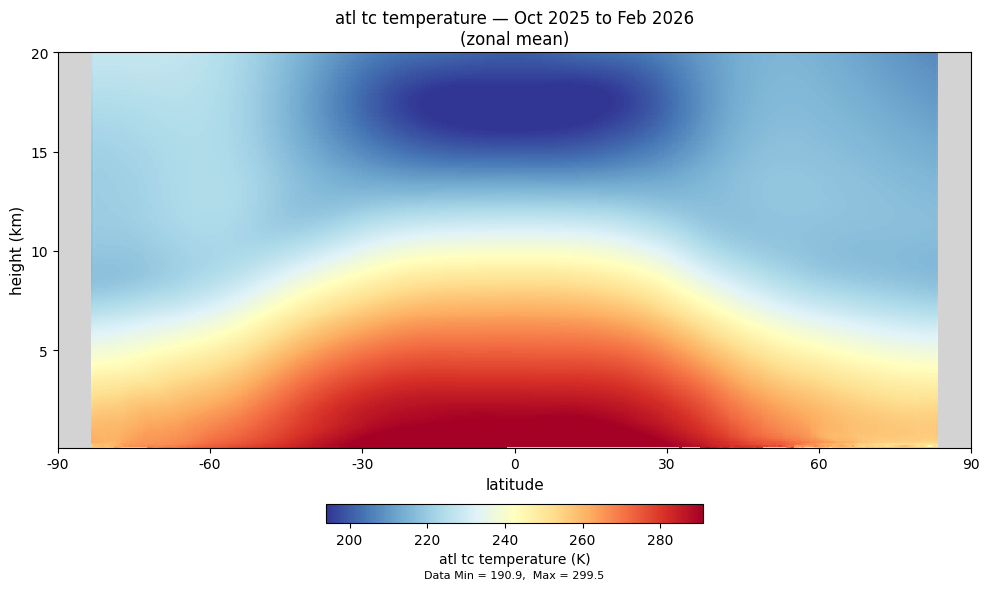

In [6]:
h_mask  = t_h <= 20.0
plot_h  = t_h[h_mask]
plot_lh = t_lh[:, h_mask]

vmin_lh = np.nanpercentile(plot_lh[np.isfinite(plot_lh)], 2)
vmax_lh = np.nanpercentile(plot_lh[np.isfinite(plot_lh)], 98)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.pcolormesh(t_lat, plot_h, plot_lh.T,
                   cmap="RdYlBu_r", vmin=vmin_lh, vmax=vmax_lh, shading="nearest")

cbar = plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.12, fraction=0.04)
cbar.set_label("atl tc temperature (K)")
cbar.ax.text(0.5, -2.5,
             f"Data Min = {np.nanmin(plot_lh):.1f},  Max = {np.nanmax(plot_lh):.1f}",
             ha="center", va="top", transform=cbar.ax.transAxes, fontsize=8)

ax.set_xlabel("latitude", fontsize=11)
ax.set_ylabel("height (km)", fontsize=11)
ax.set_xlim(-90, 90)
ax.set_ylim(0.1, 20.0)
ax.set_xticks([-90, -60, -30, 0, 30, 60, 90])
ax.set_xticklabels(["-90", "-60", "-30", "0", "30", "60", "90"])
ax.set_yticks([5, 10, 15, 20])
ax.set_yticklabels(["5", "10", "15", "20"])
ax.set_title("atl tc temperature — Oct 2025 to Feb 2026\n(zonal mean)", fontsize=12)
ax.set_facecolor("lightgrey")

plt.tight_layout()
plt.savefig(OUT_DIR / "A1.5.2_temperature_latheight.png", dpi=300, bbox_inches="tight")
print("Saved A1.5.2_temperature_latheight.png")
plt.show()

**A2. Temperature at ice pixels**

Saved A2_temperature.png


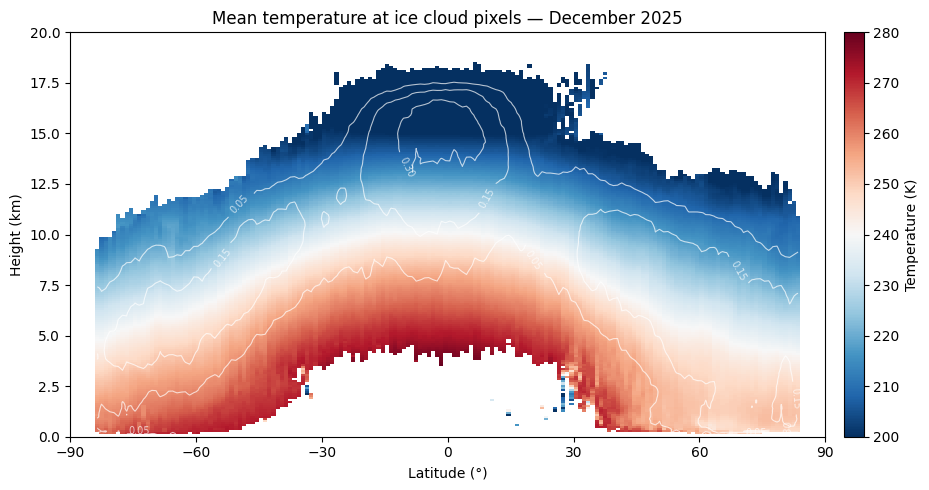

In [7]:
cross_section(temp, lat, h,
    title="Mean temperature at ice cloud pixels — December 2025",
    cbar_label="Temperature (K)",
    cmap="RdBu_r", vmin=200, vmax=280,
    fname="A2_temperature.png")

**A3. Depolarization ratio** *(key EBD plot — confirms ice vs liquid)*

Ice crystals: ~0.3–0.5. Liquid droplets: ~0.01–0.05. High depol = confirmed ice.

Saved A3_depol_ratio.png


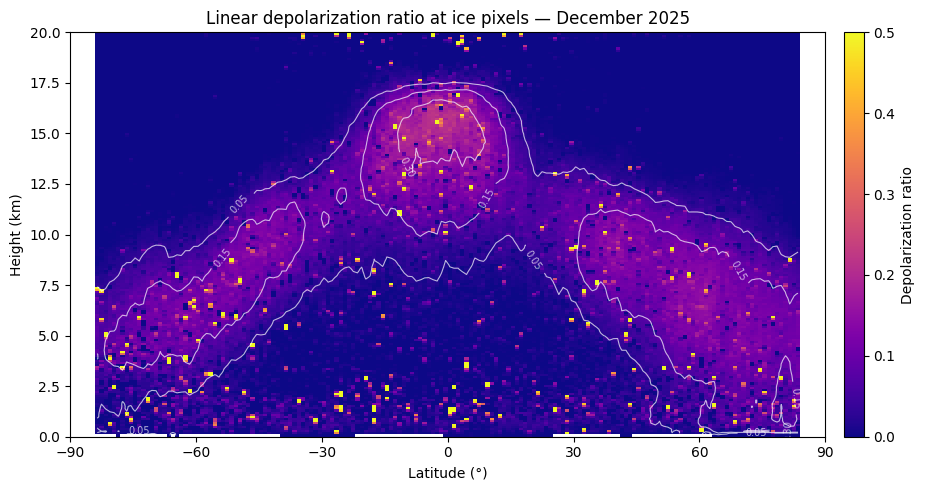

In [8]:
cross_section(depol, lat, h,
    title="Linear depolarization ratio at ice pixels — December 2025",
    cbar_label="Depolarization ratio",
    cmap="plasma", vmin=0, vmax=0.5,
    fname="A3_depol_ratio.png")

**A4. Extinction coefficient**

Shows where ice clouds are optically thick. High extinction = dense cirrus.

Saved A4_extinction.png


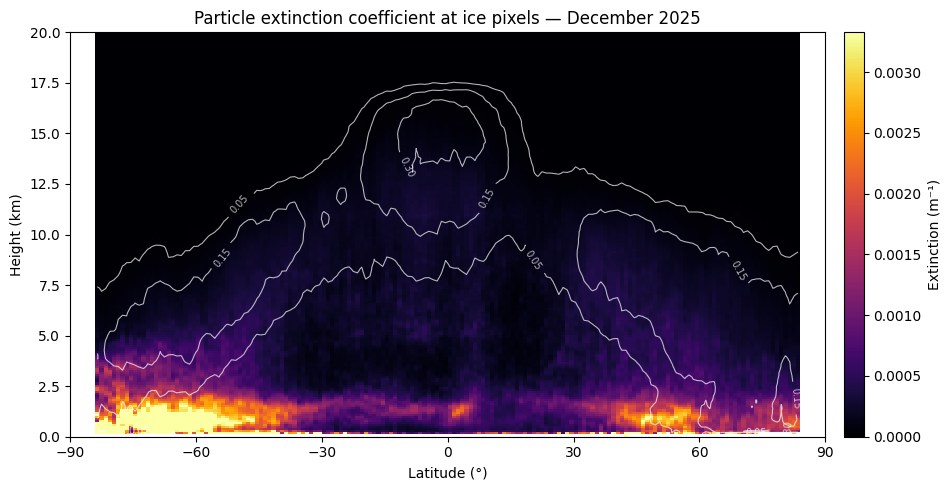

In [9]:
cross_section(ext, lat, h,
    title="Particle extinction coefficient at ice pixels — December 2025",
    cbar_label="Extinction (m⁻¹)",
    cmap="inferno",
    fname="A4_extinction.png")

**A5. Lidar ratio** *(extinction-to-backscatter ratio)*

Cirrus ice: ~18–30 sr. Varies with crystal habit and temperature.

Saved A5_lidar_ratio.png


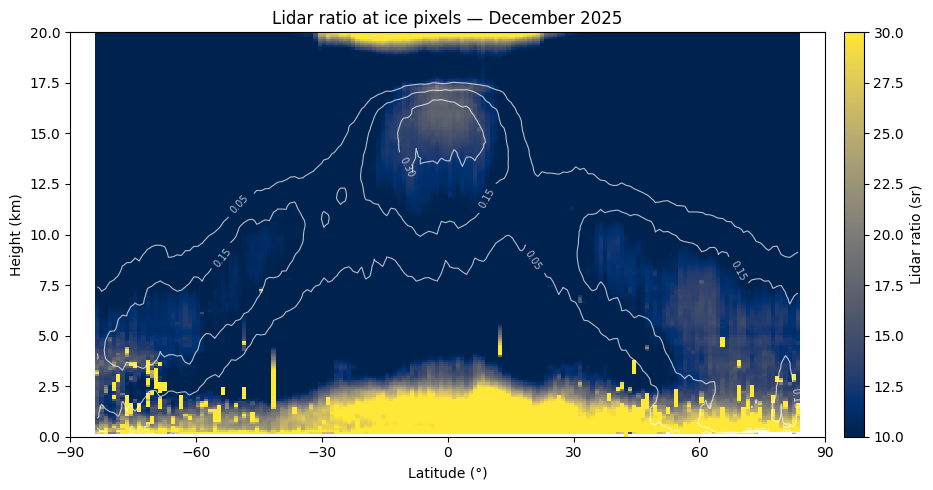

In [10]:
cross_section(lr, lat, h,
    title="Lidar ratio at ice pixels — December 2025",
    cbar_label="Lidar ratio (sr)",
    cmap="cividis", vmin=10, vmax=30,
    fname="A5_lidar_ratio.png")

**A6. Backscatter coefficient**

Saved A6_backscatter.png


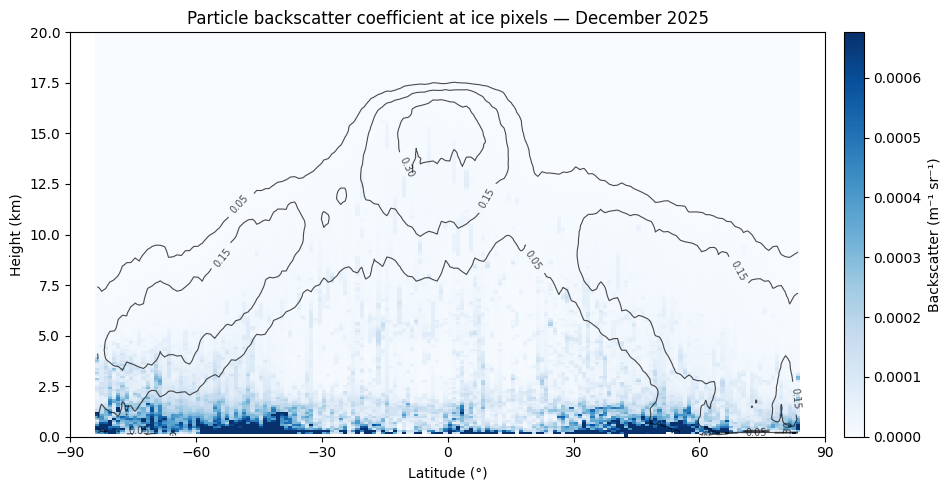

In [11]:
cross_section(bsc, lat, h,
    title="Particle backscatter coefficient at ice pixels — December 2025",
    cbar_label="Backscatter (m⁻¹ sr⁻¹)",
    cmap="Blues",
    occ_color="black",
    fname="A6_backscatter.png")

**A7. Ice water content + occurrence contours**

Saved A7_iwc_occurrence.png


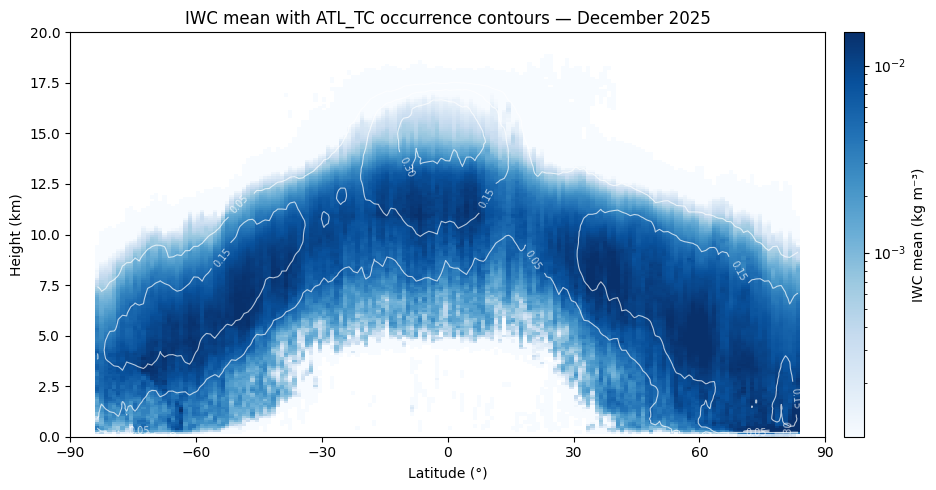

In [12]:
cross_section(iwc, lat, h,
    title="IWC mean with ATL_TC occurrence contours — December 2025",
    cbar_label="IWC mean (kg m⁻³)",
    cmap="Blues",
    log_scale=True,
    fname="A7_iwc_occurrence.png")

**A8. Effective radius**

Saved A8_eff_radius.png


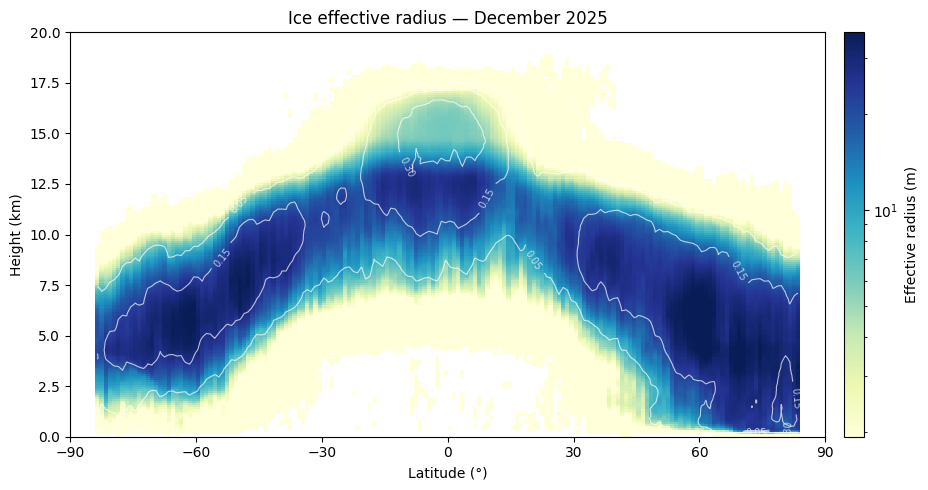

In [13]:
cross_section(reff, lat, h,
    title="Ice effective radius — December 2025",
    cbar_label="Effective radius (m)",
    cmap="YlGnBu",
    log_scale=True,
    fname="A8_eff_radius.png")

## Section B — Variability (std maps)

Low std = consistent stratiform cirrus. High std = convective outflow.

Saved B_variability_panel.png


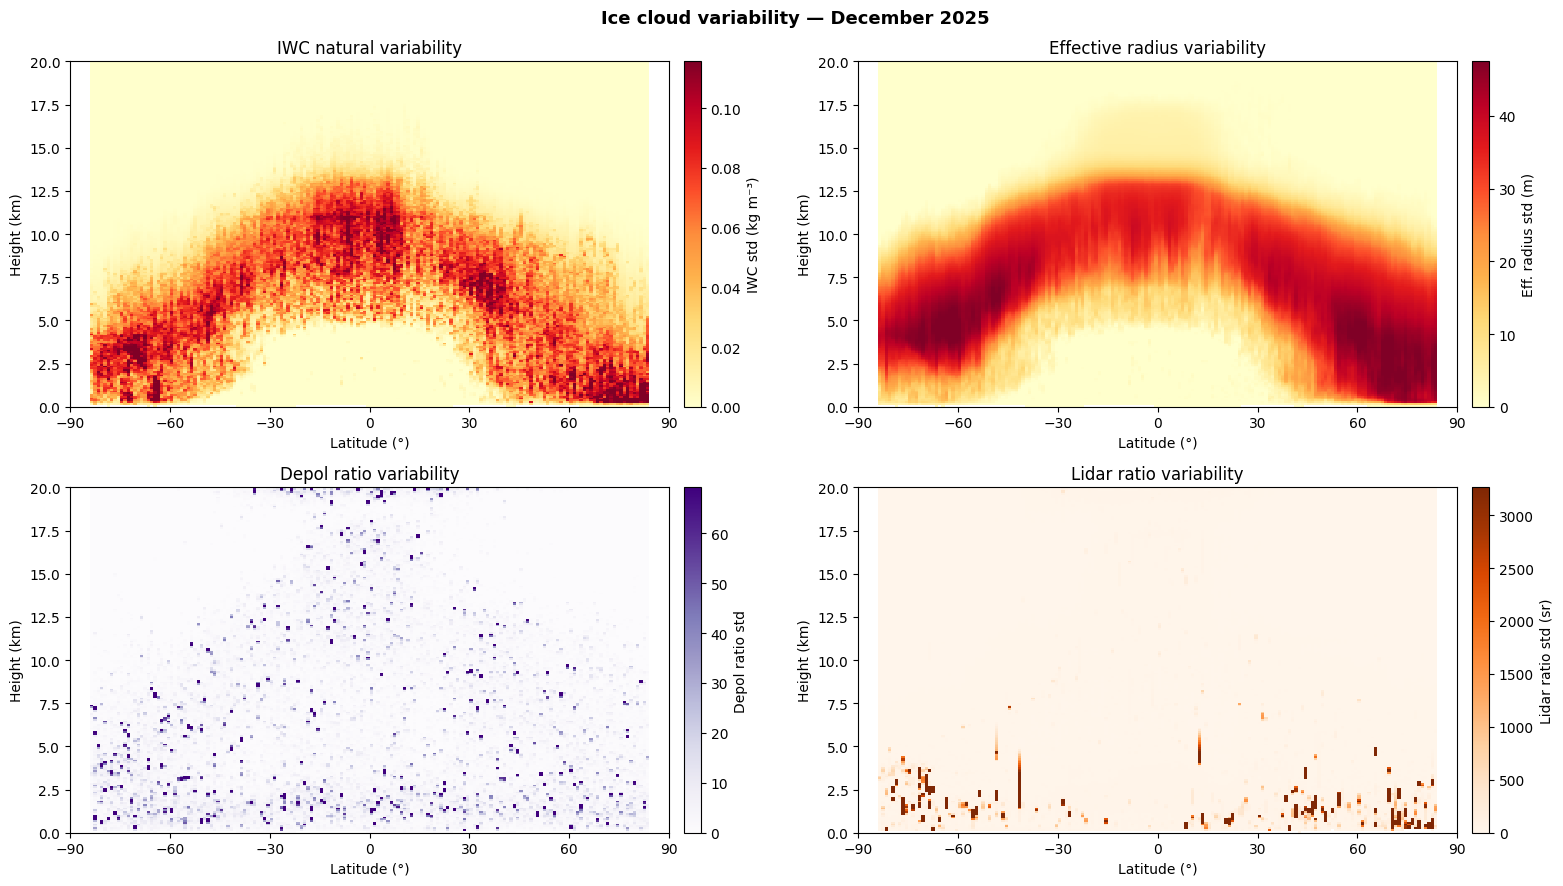

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

panels = [
    (axes[0,0], iwc_s,   "IWC std (kg m⁻³)",    "YlOrRd", "IWC natural variability"),
    (axes[0,1], reff_s,  "Eff. radius std (m)",  "YlOrRd", "Effective radius variability"),
    (axes[1,0], depol_s, "Depol ratio std",       "Purples", "Depol ratio variability"),
    (axes[1,1], lr_s,    "Lidar ratio std (sr)",  "Oranges", "Lidar ratio variability"),
]

for ax, data, cbar_label, cmap, title in panels:
    vmax = np.nanpercentile(data, 99)
    mesh = ax.pcolormesh(lat, h, data.T, cmap=cmap, vmin=0, vmax=vmax, shading="auto")
    plt.colorbar(mesh, ax=ax, label=cbar_label, pad=0.02)
    ax.set_title(title)
    ax.set_xlabel("Latitude (°)")
    ax.set_ylabel("Height (km)")
    ax.set_xlim(-90, 90)
    ax.set_xticks(range(-90, 91, 30))
    ax.set_ylim(0, 20)

fig.suptitle("Ice cloud variability — December 2025", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "B_variability_panel.png", dpi=300, bbox_inches="tight")
print("Saved B_variability_panel.png")
plt.show()

## Section C — 1D Latitudinal profiles

Height-averaged over 8–15 km (main ice cloud layer).

/var/folders/vp/b00pzthx34g6lmnpx9qphb5h0000gn/T/ipykernel_73969/1458191323.py:5: RuntimeWarning: Mean of empty slice
  "IWC (kg m⁻³)":      np.nanmean(iwc[:,  hm], axis=1),
/var/folders/vp/b00pzthx34g6lmnpx9qphb5h0000gn/T/ipykernel_73969/1458191323.py:6: RuntimeWarning: Mean of empty slice
  "Eff. radius (m)":    np.nanmean(reff[:, hm], axis=1),
/var/folders/vp/b00pzthx34g6lmnpx9qphb5h0000gn/T/ipykernel_73969/1458191323.py:7: RuntimeWarning: Mean of empty slice
  "Depol ratio":        np.nanmean(depol[:,hm], axis=1),
/var/folders/vp/b00pzthx34g6lmnpx9qphb5h0000gn/T/ipykernel_73969/1458191323.py:8: RuntimeWarning: Mean of empty slice
  "Extinction (m⁻¹)":  np.nanmean(ext[:,  hm], axis=1),
/var/folders/vp/b00pzthx34g6lmnpx9qphb5h0000gn/T/ipykernel_73969/1458191323.py:9: RuntimeWarning: Mean of empty slice
  "Lidar ratio (sr)":   np.nanmean(lr[:,   hm], axis=1),
/var/folders/vp/b00pzthx34g6lmnpx9qphb5h0000gn/T/ipykernel_73969/1458191323.py:10: RuntimeWarning: Mean of empty slice
  "Occur

Saved C_latitudinal_profiles.png


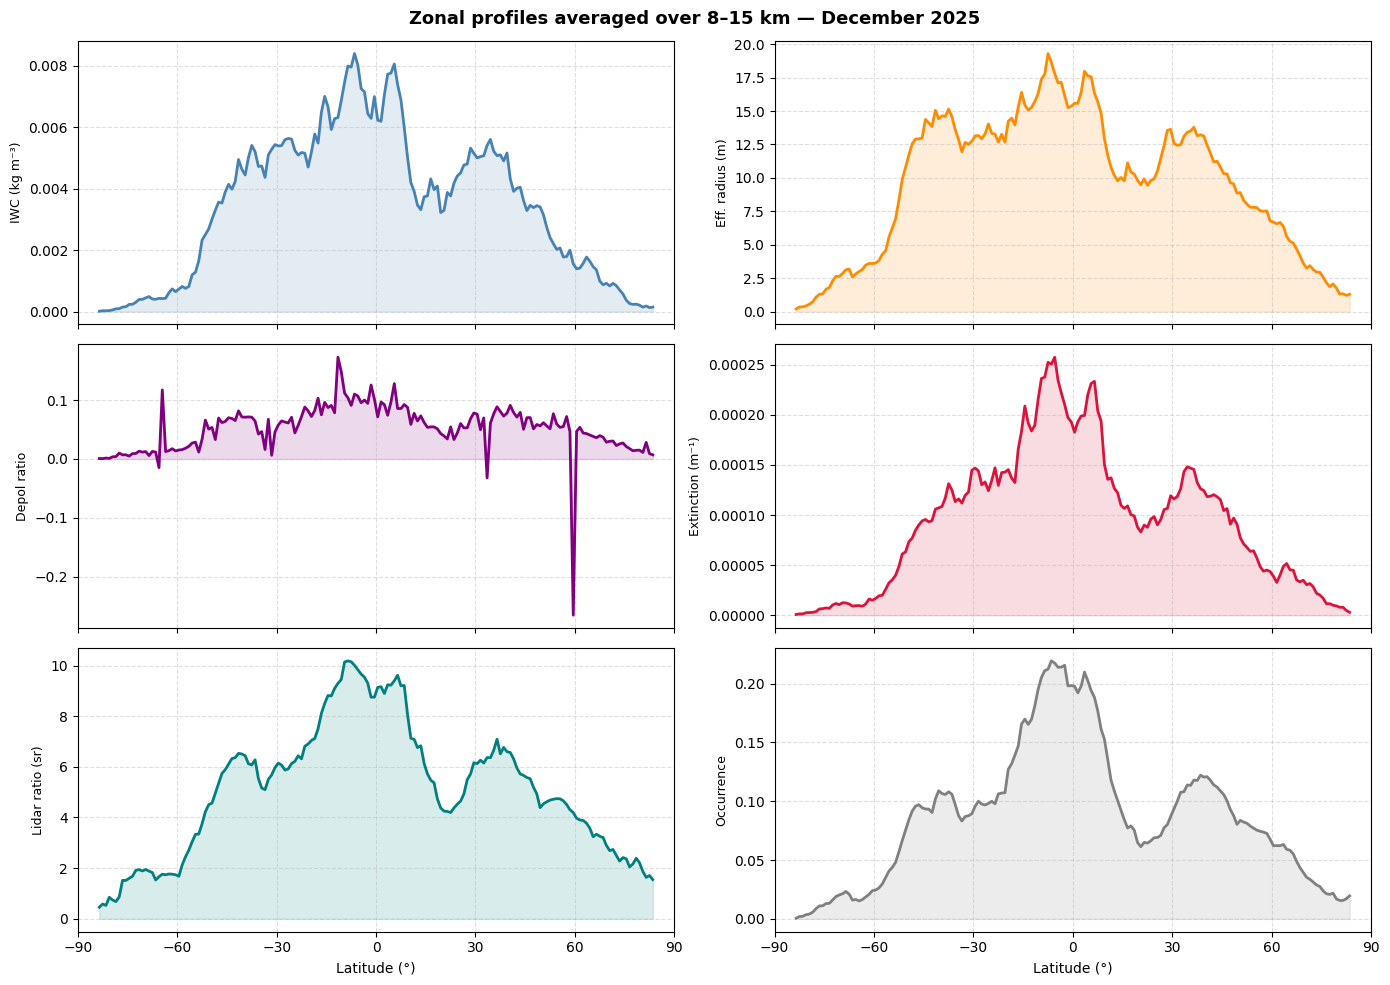

In [15]:
H_MIN, H_MAX = 8.0, 15.0
hm = (h >= H_MIN) & (h <= H_MAX)

profiles = {
    "IWC (kg m⁻³)":      np.nanmean(iwc[:,  hm], axis=1),
    "Eff. radius (m)":    np.nanmean(reff[:, hm], axis=1),
    "Depol ratio":        np.nanmean(depol[:,hm], axis=1),
    "Extinction (m⁻¹)":  np.nanmean(ext[:,  hm], axis=1),
    "Lidar ratio (sr)":   np.nanmean(lr[:,   hm], axis=1),
    "Occurrence":         np.nanmean(occ[:,  hm], axis=1),
}

colors = ["steelblue", "darkorange", "purple", "crimson", "teal", "gray"]

fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
for ax, (label, profile), color in zip(axes.ravel(), profiles.items(), colors):
    ax.plot(lat, profile, color=color, lw=2)
    ax.fill_between(lat, 0, profile, alpha=0.15, color=color)
    ax.set_ylabel(label, fontsize=9)
    ax.set_xlim(-90, 90)
    ax.set_xticks(range(-90, 91, 30))
    ax.grid(True, ls="--", alpha=0.4)

for ax in axes[-1]:
    ax.set_xlabel("Latitude (°)")

fig.suptitle(f"Zonal profiles averaged over {H_MIN:.0f}–{H_MAX:.0f} km — December 2025",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "C_latitudinal_profiles.png", dpi=300, bbox_inches="tight")
print("Saved C_latitudinal_profiles.png")
plt.show()

**C2. Column optical depth** (integrate extinction over full height)

Saved C2_optical_depth.png


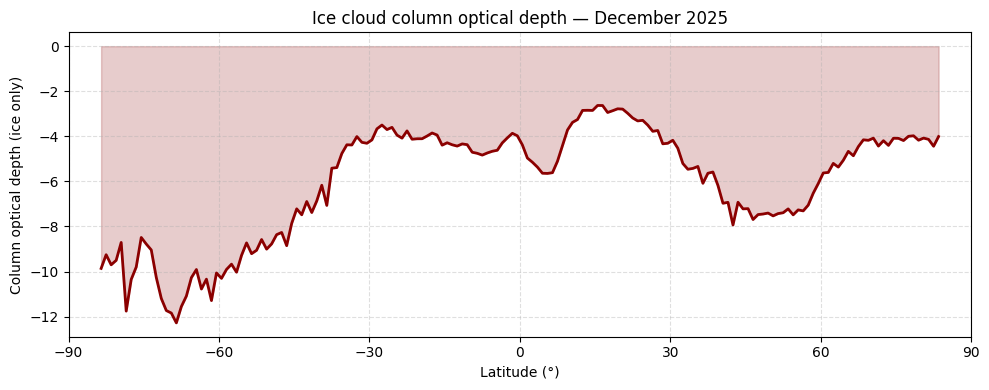

In [16]:
# Optical depth = integral of extinction over height (trapezoidal rule)
dh = np.gradient(h) * 1000   # km → m for consistent units with ext [m⁻¹]
ext_filled = np.where(np.isfinite(ext), ext, 0.0)
od = np.sum(ext_filled * dh[np.newaxis, :], axis=1)   # (lat,)
od[od == 0] = np.nan

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(lat, od, color="darkred", lw=2)
ax.fill_between(lat, 0, od, alpha=0.2, color="darkred")
ax.set_xlabel("Latitude (°)")
ax.set_ylabel("Column optical depth (ice only)")
ax.set_title("Ice cloud column optical depth — December 2025")
ax.set_xlim(-90, 90)
ax.set_xticks(range(-90, 91, 30))
ax.grid(True, ls="--", alpha=0.4)
plt.tight_layout()
plt.savefig(OUT_DIR / "C2_optical_depth.png", dpi=300)
print("Saved C2_optical_depth.png")
plt.show()

## Section D — Scatter plots (height-integrated, one point per latitude)

**D1. Depolarization ratio vs effective radius**

Larger/more irregular particles → higher depolarization. A physical ice microphysics result.

Saved D1_depol_vs_reff.png


/var/folders/vp/b00pzthx34g6lmnpx9qphb5h0000gn/T/ipykernel_73969/1349197967.py:1: RuntimeWarning: Mean of empty slice
  d_lat  = np.nanmean(depol, axis=1)
/var/folders/vp/b00pzthx34g6lmnpx9qphb5h0000gn/T/ipykernel_73969/1349197967.py:2: RuntimeWarning: Mean of empty slice
  r_lat  = np.nanmean(reff,  axis=1)


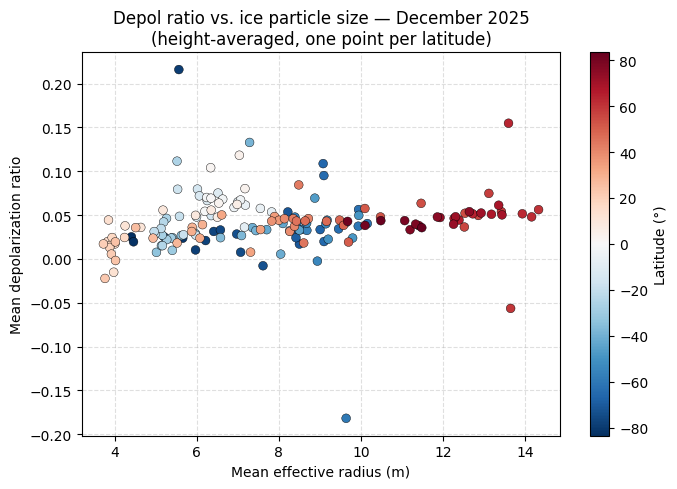

In [17]:
d_lat  = np.nanmean(depol, axis=1)
r_lat  = np.nanmean(reff,  axis=1)
mask = np.isfinite(d_lat) & np.isfinite(r_lat)

fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(r_lat[mask], d_lat[mask], c=lat[mask], cmap="RdBu_r",
                s=40, edgecolors="k", linewidths=0.3, zorder=3)
plt.colorbar(sc, ax=ax, label="Latitude (°)")
ax.set_xlabel("Mean effective radius (m)")
ax.set_ylabel("Mean depolarization ratio")
ax.set_title("Depol ratio vs. ice particle size — December 2025\n"
             "(height-averaged, one point per latitude)")
ax.grid(True, ls="--", alpha=0.4)
plt.tight_layout()
plt.savefig(OUT_DIR / "D1_depol_vs_reff.png", dpi=300)
print("Saved D1_depol_vs_reff.png")
plt.show()

**D2. Extinction vs IWC**

Should correlate strongly — more ice mass = more extinction. Slope = specific extinction.

/var/folders/vp/b00pzthx34g6lmnpx9qphb5h0000gn/T/ipykernel_73969/4090113565.py:1: RuntimeWarning: Mean of empty slice
  e_lat   = np.nanmean(ext,  axis=1)
/var/folders/vp/b00pzthx34g6lmnpx9qphb5h0000gn/T/ipykernel_73969/4090113565.py:2: RuntimeWarning: Mean of empty slice
  iwc_lat = np.nanmean(iwc,  axis=1)


Saved D2_extinction_vs_iwc.png


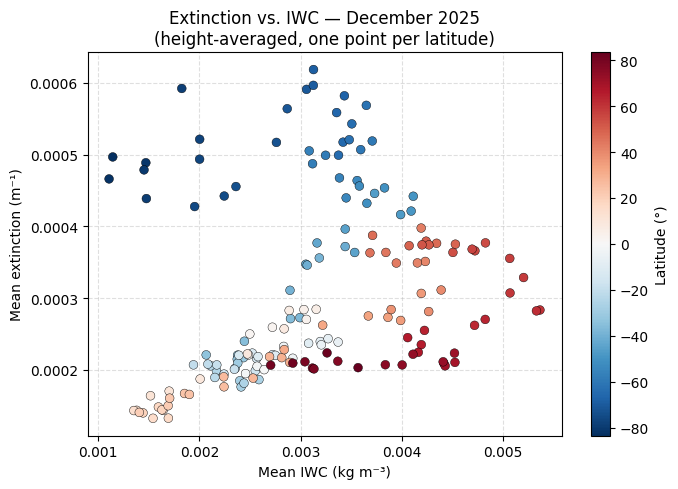

In [18]:
e_lat   = np.nanmean(ext,  axis=1)
iwc_lat = np.nanmean(iwc,  axis=1)
mask = np.isfinite(e_lat) & np.isfinite(iwc_lat)

fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(iwc_lat[mask], e_lat[mask], c=lat[mask], cmap="RdBu_r",
                s=40, edgecolors="k", linewidths=0.3, zorder=3)
plt.colorbar(sc, ax=ax, label="Latitude (°)")
ax.set_xlabel("Mean IWC (kg m⁻³)")
ax.set_ylabel("Mean extinction (m⁻¹)")
ax.set_title("Extinction vs. IWC — December 2025\n"
             "(height-averaged, one point per latitude)")
ax.grid(True, ls="--", alpha=0.4)
plt.tight_layout()
plt.savefig(OUT_DIR / "D2_extinction_vs_iwc.png", dpi=300)
print("Saved D2_extinction_vs_iwc.png")
plt.show()

**D3. Depolarization ratio vs temperature**

Colder = smaller, more irregular crystals = higher depol expected.

/var/folders/vp/b00pzthx34g6lmnpx9qphb5h0000gn/T/ipykernel_73969/846842095.py:1: RuntimeWarning: Mean of empty slice
  d_lat = np.nanmean(depol, axis=1)
/var/folders/vp/b00pzthx34g6lmnpx9qphb5h0000gn/T/ipykernel_73969/846842095.py:2: RuntimeWarning: Mean of empty slice
  T_lat = np.nanmean(temp,  axis=1)


Saved D3_depol_vs_temperature.png


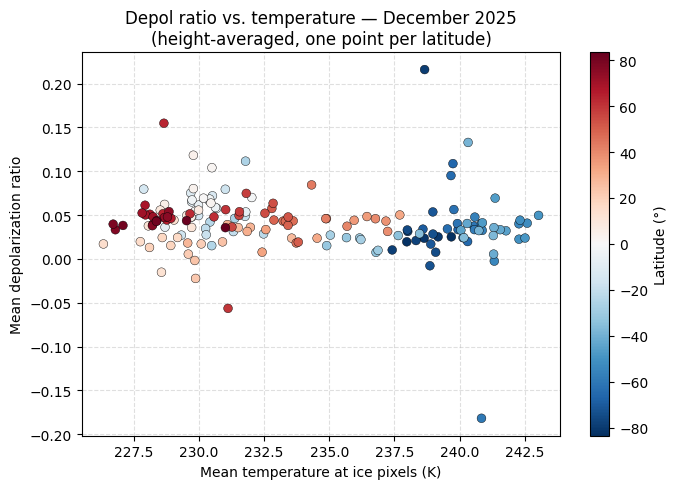

In [19]:
d_lat = np.nanmean(depol, axis=1)
T_lat = np.nanmean(temp,  axis=1)
mask  = np.isfinite(d_lat) & np.isfinite(T_lat)

fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(T_lat[mask], d_lat[mask], c=lat[mask], cmap="RdBu_r",
                s=40, edgecolors="k", linewidths=0.3, zorder=3)
plt.colorbar(sc, ax=ax, label="Latitude (°)")
ax.set_xlabel("Mean temperature at ice pixels (K)")
ax.set_ylabel("Mean depolarization ratio")
ax.set_title("Depol ratio vs. temperature — December 2025\n"
             "(height-averaged, one point per latitude)")
ax.grid(True, ls="--", alpha=0.4)
plt.tight_layout()
plt.savefig(OUT_DIR / "D3_depol_vs_temperature.png", dpi=300)
print("Saved D3_depol_vs_temperature.png")
plt.show()

**D4. Temperature vs effective radius** *(from Presentation_Plots, reproduced here)*

/var/folders/vp/b00pzthx34g6lmnpx9qphb5h0000gn/T/ipykernel_73969/3335198197.py:1: RuntimeWarning: Mean of empty slice
  T_lat   = np.nanmean(temp, axis=1)
/var/folders/vp/b00pzthx34g6lmnpx9qphb5h0000gn/T/ipykernel_73969/3335198197.py:2: RuntimeWarning: Mean of empty slice
  r_lat   = np.nanmean(reff, axis=1)


Saved D4_T_vs_reff.png


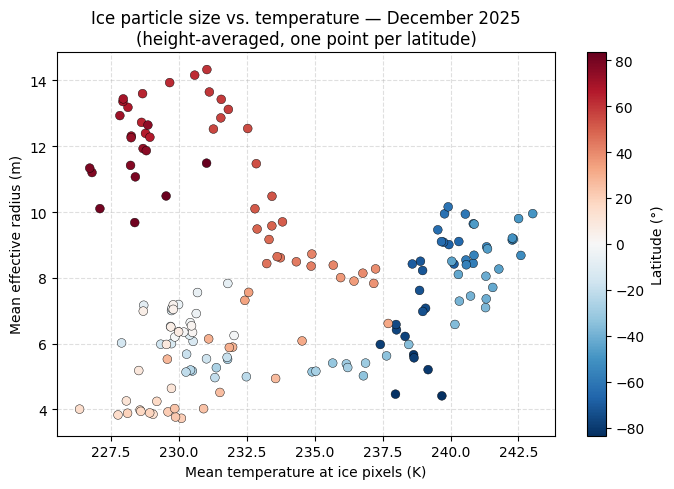

In [20]:
T_lat   = np.nanmean(temp, axis=1)
r_lat   = np.nanmean(reff, axis=1)
mask    = np.isfinite(T_lat) & np.isfinite(r_lat)

fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(T_lat[mask], r_lat[mask], c=lat[mask], cmap="RdBu_r",
                s=40, edgecolors="k", linewidths=0.3, zorder=3)
plt.colorbar(sc, ax=ax, label="Latitude (°)")
ax.set_xlabel("Mean temperature at ice pixels (K)")
ax.set_ylabel("Mean effective radius (m)")
ax.set_title("Ice particle size vs. temperature — December 2025\n"
             "(height-averaged, one point per latitude)")
ax.grid(True, ls="--", alpha=0.4)
plt.tight_layout()
plt.savefig(OUT_DIR / "D4_T_vs_reff.png", dpi=300)
print("Saved D4_T_vs_reff.png")
plt.show()

**D5. Lidar ratio vs depolarization ratio**

Both are shape/habit-sensitive: irregular crystals increase depol *and* tend to raise the lidar ratio. A positive correlation would confirm a shared microphysical driver.

/var/folders/vp/b00pzthx34g6lmnpx9qphb5h0000gn/T/ipykernel_73969/3357197492.py:3: RuntimeWarning: Mean of empty slice
  lr_lat    = np.nanmean(lr,    axis=1)
/var/folders/vp/b00pzthx34g6lmnpx9qphb5h0000gn/T/ipykernel_73969/3357197492.py:4: RuntimeWarning: Mean of empty slice
  d_lat     = np.nanmean(depol, axis=1)


Saved D5_lr_vs_depol.png
N = 90/168 points
Pearson  r = 0.140  p = 1.88e-01
Spearman r = 0.217  p = 4.03e-02


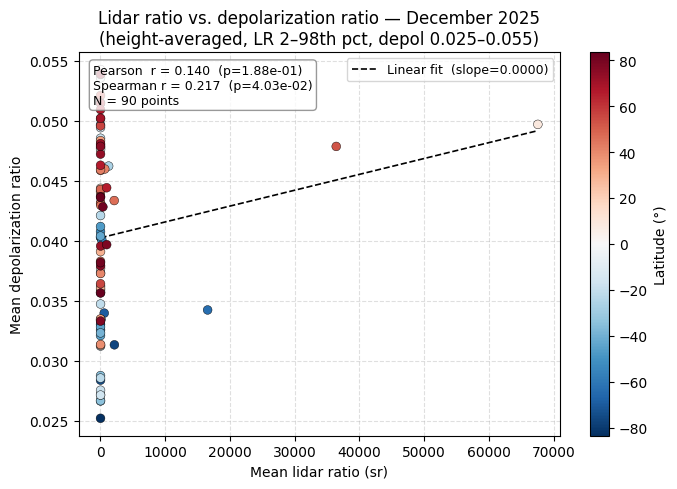

In [21]:
from scipy.stats import pearsonr, spearmanr

lr_lat    = np.nanmean(lr,    axis=1)
d_lat     = np.nanmean(depol, axis=1)
mask      = np.isfinite(lr_lat) & np.isfinite(d_lat)

P_LO, P_HI         = 2, 98
DEPOL_MIN, DEPOL_MAX = 0.025, 0.055

lr_lo, lr_hi = np.nanpercentile(lr_lat[mask], [P_LO, P_HI])
clip = (mask
        & (lr_lat >= lr_lo)    & (lr_lat <= lr_hi)
        & (d_lat  >= DEPOL_MIN) & (d_lat  <= DEPOL_MAX))

r_p, p_p = pearsonr( lr_lat[clip], d_lat[clip])
r_s, p_s = spearmanr(lr_lat[clip], d_lat[clip])

coeffs = np.polyfit(lr_lat[clip], d_lat[clip], 1)
x_fit  = np.linspace(lr_lat[clip].min(), lr_lat[clip].max(), 200)

fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(lr_lat[clip], d_lat[clip], c=lat[clip], cmap="RdBu_r",
                s=40, edgecolors="k", linewidths=0.3, zorder=3)
ax.plot(x_fit, np.polyval(coeffs, x_fit), color="k", lw=1.2,
        ls="--", label=f"Linear fit  (slope={coeffs[0]:.4f})")
plt.colorbar(sc, ax=ax, label="Latitude (°)")
ax.set_xlabel("Mean lidar ratio (sr)")
ax.set_ylabel("Mean depolarization ratio")
ax.set_title(f"Lidar ratio vs. depolarization ratio — December 2025\n"
             f"(height-averaged, LR {P_LO}–{P_HI}th pct, depol {DEPOL_MIN}–{DEPOL_MAX})")
ax.legend(fontsize=9)
ax.grid(True, ls="--", alpha=0.4)

stats_txt = (f"Pearson  r = {r_p:.3f}  (p={p_p:.2e})\n"
             f"Spearman r = {r_s:.3f}  (p={p_s:.2e})\n"
             f"N = {clip.sum()} points")
ax.text(0.03, 0.97, stats_txt, transform=ax.transAxes,
        va="top", ha="left", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="grey", alpha=0.8))

plt.tight_layout()
plt.savefig(OUT_DIR / "D5_lr_vs_depol.png", dpi=300)
print("Saved D5_lr_vs_depol.png")
print(f"N = {clip.sum()}/{mask.sum()} points")
print(f"Pearson  r = {r_p:.3f}  p = {p_p:.2e}")
print(f"Spearman r = {r_s:.3f}  p = {p_s:.2e}")
plt.show()

**D5b. Lidar ratio vs depolarization ratio — longitude-averaged (one point per lat/height cell)**

Saved D5b_lr_vs_depol_filtered.png
N = 3811/32415 cells
Pearson  r = 0.000  p = 9.83e-01
Spearman r = 0.123  p = 2.21e-14


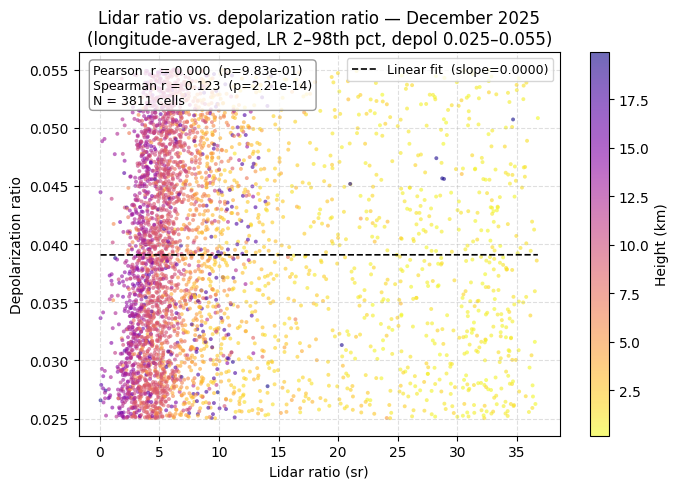

In [22]:
from scipy.stats import pearsonr, spearmanr

lr_flat    = lr.ravel()
depol_flat = depol.ravel()
h_flat     = np.tile(h, lr.shape[0])
mask       = np.isfinite(lr_flat) & np.isfinite(depol_flat)

P_LO, P_HI          = 2, 98
DEPOL_MIN, DEPOL_MAX = 0.025, 0.055

lr_lo, lr_hi = np.nanpercentile(lr_flat[mask], [P_LO, P_HI])
clip = (mask
        & (lr_flat    >= lr_lo)    & (lr_flat    <= lr_hi)
        & (depol_flat >= DEPOL_MIN) & (depol_flat <= DEPOL_MAX))

r_p, p_p = pearsonr( lr_flat[clip], depol_flat[clip])
r_s, p_s = spearmanr(lr_flat[clip], depol_flat[clip])

coeffs = np.polyfit(lr_flat[clip], depol_flat[clip], 1)
x_fit  = np.linspace(lr_flat[clip].min(), lr_flat[clip].max(), 200)

fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(lr_flat[clip], depol_flat[clip], c=h_flat[clip], cmap="plasma_r",
                s=8, alpha=0.6, linewidths=0)
ax.plot(x_fit, np.polyval(coeffs, x_fit), color="k", lw=1.2,
        ls="--", label=f"Linear fit  (slope={coeffs[0]:.4f})")
plt.colorbar(sc, ax=ax, label="Height (km)")
ax.set_xlabel("Lidar ratio (sr)")
ax.set_ylabel("Depolarization ratio")
ax.set_title(f"Lidar ratio vs. depolarization ratio — December 2025\n"
             f"(longitude-averaged, LR {P_LO}–{P_HI}th pct, depol {DEPOL_MIN}–{DEPOL_MAX})")
ax.legend(fontsize=9)
ax.grid(True, ls="--", alpha=0.4)

stats_txt = (f"Pearson  r = {r_p:.3f}  (p={p_p:.2e})\n"
             f"Spearman r = {r_s:.3f}  (p={p_s:.2e})\n"
             f"N = {clip.sum()} cells")
ax.text(0.03, 0.97, stats_txt, transform=ax.transAxes,
        va="top", ha="left", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="grey", alpha=0.8))

plt.tight_layout()
plt.savefig(OUT_DIR / "D5b_lr_vs_depol_filtered.png", dpi=300)
print("Saved D5b_lr_vs_depol_filtered.png")
print(f"N = {clip.sum()}/{mask.sum()} cells")
print(f"Pearson  r = {r_p:.3f}  p = {p_p:.2e}")
print(f"Spearman r = {r_s:.3f}  p = {p_s:.2e}")
plt.show()

**Summary of saved figures**

In [23]:
figs = sorted(OUT_DIR.glob("*.png"))
print(f"Figures in {OUT_DIR}:")
for f in figs:
    print(f"  {f.name}")

ds.close()

Figures in /Users/tobiasraucher/Python/KNMI/output/figures:
  A1.5.1_temperature_worldmap.png
  A1.5.2_temperature_latheight.png
  A1_atl_tc_occurrence.png
  A2_temperature.png
  A3_depol_ratio.png
  A4_extinction.png
  A5_lidar_ratio.png
  A6_backscatter.png
  A7_iwc_occurrence.png
  A8_eff_radius.png
  B_variability_panel.png
  C2_optical_depth.png
  C_latitudinal_profiles.png
  D1_depol_vs_reff.png
  D2_extinction_vs_iwc.png
  D3_depol_vs_temperature.png
  D4_T_vs_reff.png
  D5_lr_vs_depol.png
  D5b_lr_vs_depol_filtered.png
  plot1_iwc_occurrence_overlay.png
  plot2_variability.png
  plot3_iwc_lat_profile.png
  plot4_T_vs_iwc.png
  plot5_pipeline.png
